In [35]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

cust_df = pd.read_csv('./data/Mall_Customers.csv')
cust_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [37]:
# CustomerID 제거, 성별 인코딩
cust_df['Gender'] = (cust_df['Gender'] == 'Male').astype(int)
X = cust_df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Gender']].values
X

array([[ 19,  15,  39,   1],
       [ 21,  15,  81,   1],
       [ 20,  16,   6,   0],
       [ 23,  16,  77,   0],
       [ 31,  17,  40,   0],
       [ 22,  17,  76,   0],
       [ 35,  18,   6,   0],
       [ 23,  18,  94,   0],
       [ 64,  19,   3,   1],
       [ 30,  19,  72,   0],
       [ 67,  19,  14,   1],
       [ 35,  19,  99,   0],
       [ 58,  20,  15,   0],
       [ 24,  20,  77,   0],
       [ 37,  20,  13,   1],
       [ 22,  20,  79,   1],
       [ 35,  21,  35,   0],
       [ 20,  21,  66,   1],
       [ 52,  23,  29,   1],
       [ 35,  23,  98,   0],
       [ 35,  24,  35,   1],
       [ 25,  24,  73,   1],
       [ 46,  25,   5,   0],
       [ 31,  25,  73,   1],
       [ 54,  28,  14,   0],
       [ 29,  28,  82,   1],
       [ 45,  28,  32,   0],
       [ 35,  28,  61,   1],
       [ 40,  29,  31,   0],
       [ 23,  29,  87,   0],
       [ 60,  30,   4,   1],
       [ 21,  30,  73,   0],
       [ 53,  33,   4,   1],
       [ 18,  33,  92,   1],
       [ 49,  

In [38]:
# 3. 피처 분리
X = cust_df[['Gender', 'Age', 
             'Annual Income (k$)', 
             'Spending Score (1-100)']]

# 4. 스케일링
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [39]:
X_scaled[:3]

array([[ 1.12815215, -1.42456879, -1.73899919, -0.43480148],
       [ 1.12815215, -1.28103541, -1.73899919,  1.19570407],
       [-0.88640526, -1.3528021 , -1.70082976, -1.71591298]])

In [40]:
# PCA : 2개의 주성분으로 압축
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("설명 분산 비율:", pca.explained_variance_ratio_)
print("누적 설명 분산:", sum(pca.explained_variance_ratio_))

설명 분산 비율: [0.33690046 0.26230645]
누적 설명 분산: 0.5992069019819846


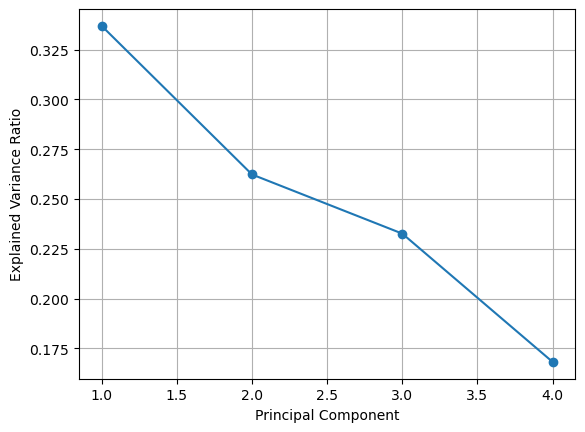

In [41]:
# 스크리차트로 k 확인
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca_full = PCA() #default는 x의 컬럼수 4개로 설정
pca_full.fit(X_scaled)

plt.plot(range(1, len(pca_full.explained_variance_ratio_)+1),
         pca_full.explained_variance_ratio_, marker='o')
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.grid()
plt.show()

In [42]:
# KMEANS 클러스터링 
from sklearn.cluster import KMeans

# 클러스터 수 설정 (예: 3)
kmeans = KMeans(n_clusters=3, random_state=42)

# 2차원 PCA 데이터로 학습 및 예측
cust_df['cluster'] = kmeans.fit_predict(X_pca)

# 각 클러스터 중심 확인 (PCA 좌표 기준)
centers = kmeans.cluster_centers_
print("클러스터 중심 (PC1, PC2):")
print(centers)

클러스터 중심 (PC1, PC2):
[[ 1.10071763 -0.2051407 ]
 [-0.55518416  1.21366365]
 [-1.04811885 -0.56688488]]


c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarn

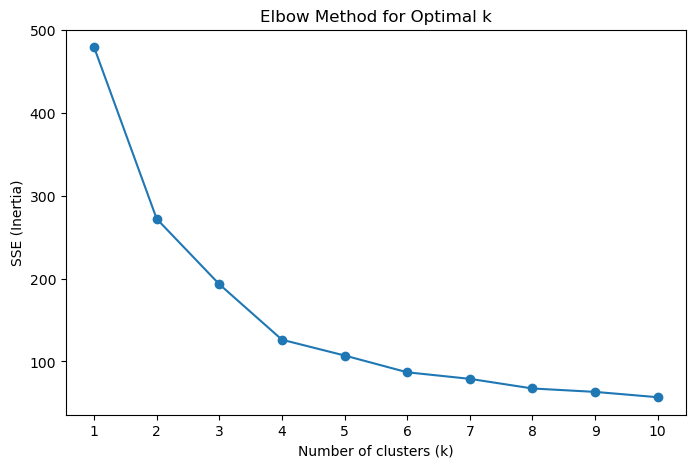

In [43]:
# 엘보우 기법으로 k값 결정
sse = []
K_range = range(1, 11)  # k=1~10까지

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_pca)
    sse.append(kmeans.inertia_)  # inertia_ = SSE
    
plt.figure(figsize=(8,5))
plt.plot(K_range, sse, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("SSE (Inertia)")
plt.title("Elbow Method for Optimal k")
plt.xticks(K_range)
plt.show()

In [ ]:
# X_pca
# cust_df

In [44]:
k = 4
kmeans = KMeans(n_clusters=k, random_state=42)
clusters = kmeans.fit_predict(X_pca)

# 데이터프레임에 클러스터 결과 추가
cust_df['cluster_4'] = clusters

# 클러스터 중심
centers = kmeans.cluster_centers_

c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [45]:
cust_df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),cluster,cluster_4
0,1,1,19,15,39,2,2
1,2,1,21,15,81,2,2
2,3,0,20,16,6,2,1
3,4,0,23,16,77,2,2
4,5,0,31,17,40,2,1
...,...,...,...,...,...,...,...
195,196,0,35,120,79,1,3
196,197,0,45,126,28,1,0
197,198,1,32,126,74,1,3
198,199,1,32,137,18,1,3


In [ ]:
# KMeans 클러스터링 결과 시각화

In [46]:
from sklearn.metrics import silhouette_samples, silhouette_score

clusters = cust_df['cluster_4'].values
k = 4  # 클러스터 수

# 전체 실루엣 점수
sil_score = silhouette_score(X_pca, clusters)
print(f"전체 실루엣 점수: {sil_score:.3f}")

# 개별 샘플 실루엣 점수
sample_silhouette_values = silhouette_samples(X_pca, clusters)
cust_df['silhouette'] = sample_silhouette_values

전체 실루엣 점수: 0.412


In [ ]:
# cust_df

In [47]:
import matplotlib.cm as cm

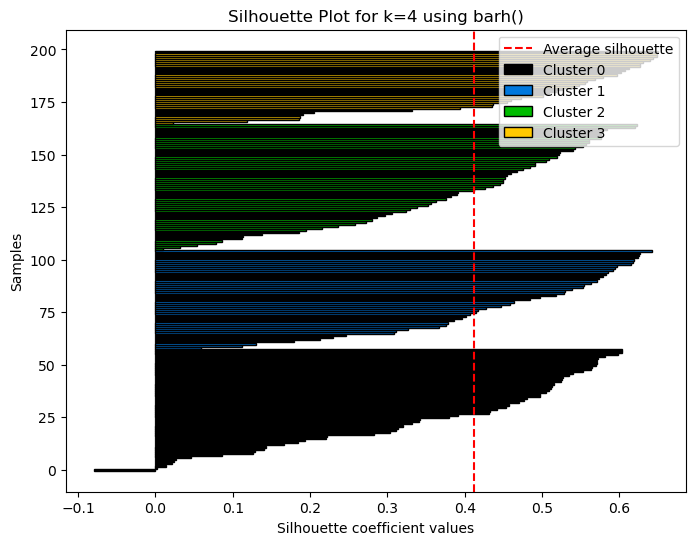

In [48]:
plt.figure(figsize=(8,6))

cluster_colors = cm.nipy_spectral(np.arange(k) / k)
y_pos = 0  # y축 위치 초기화

for i in range(k):
    values = sample_silhouette_values[clusters == i]
    values.sort()
    
    # 수평 막대(barh) 그리기
    plt.barh(
        np.arange(y_pos, y_pos + len(values)),
        values,
        color=cluster_colors[i],
        edgecolor='k',
        label=f'Cluster {i}'
    )
    
    y_pos += len(values)

# 평균 실루엣 점수 선
plt.axvline(x=sil_score, color='red', linestyle='--', label='Average silhouette')

plt.xlabel("Silhouette coefficient values")
plt.ylabel("Samples")
plt.title(f"Silhouette Plot for k={k} using barh()")
plt.legend(loc='upper right')
plt.show()

# 4개의 클러스터의 특징을 요약

In [49]:
# 클러스터 컬럼 추가 (만약 없으면)
#cust_df['cluster_4'] = clusters

# 주요 피처 선택
features = ['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

# 그룹별 요약
cluster_summary = cust_df.groupby('cluster_4')[features].mean().round(2)
cluster_counts = cust_df['cluster_4'].value_counts().sort_index()

# 클러스터별 샘플 수도 함께 표시
cluster_summary['Count'] = cluster_counts

print(cluster_summary)

           Gender    Age  Annual Income (k$)  Spending Score (1-100)  Count
cluster_4                                                                  
0            0.78  49.07               70.34                   28.57     58
1            0.06  47.68               45.21                   37.81     47
2            0.18  27.23               49.98                   67.93     60
3            0.83  29.97               83.09                   72.29     35
